# STIC-JPL Sensitivity Analysis with ECOv002 Cal-Val

This notebook performs a sensitivity analysis of the STIC-JPL model using ECOSTRESS Collection 2 Cal-Val data. It loads input data, processes it through the STIC-JPL model, and visualizes the impact of input perturbations on latent heat flux. The notebook also generates figures for publication and explores the relationship between surface temperature and latent heat flux.

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the PT-JPL-SM model, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

In [2]:
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from verma_net_radiation import verma_net_radiation_table
from BESS_JPL import process_BESS_table, load_ECOv002_calval_BESS_inputs
from STIC_JPL import process_STIC_table, load_ECOv002_calval_STIC_inputs
from monte_carlo_sensitivity import perturbed_run, sensitivity_analysis, divide_absolute_by_unperturbed
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Set Normalization Function

This cell assigns the normalization function used to compare perturbed model outputs to the unperturbed baseline. The function `divide_absolute_by_unperturbed` is used for normalization in the sensitivity analysis.

In [3]:
normalization_function = divide_absolute_by_unperturbed

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function and filters out rows where `fAPARmax` is zero. The resulting DataFrame is displayed for inspection.

In [4]:
input_df = load_ECOv002_calval_STIC_inputs()

BESS_input_df = load_ECOv002_calval_BESS_inputs()

for column in BESS_input_df.columns:
    if column not in input_df.columns:
        input_df[column] = BESS_input_df[column]

if "Ta" in input_df and "Ta_C" not in input_df:
    # input_df.rename({"Ta": "Ta_C"}, inplace=True)
    input_df["Ta_C"] = input_df["Ta"]

input_df = input_df[input_df.NDVI.apply(lambda NDVI: NDVI > 0.05)]

input_df = input_df[input_df.ST_C <= 50]
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,ozone_cm,Rn_Wm2,date_UTC,SZA_deg,day_of_year,hour_of_day,lat,lon,PAR_albedo,NIR_albedo
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,0.3,393.85710,2019-10-02,48.498672,275,14.039600,35.7990,-76.6560,0.093910,0.355875
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,0.3,643.47500,2019-06-23,21.621839,174,12.907533,41.8222,-80.6370,0.025246,0.203385
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,0.3,628.76870,2019-06-27,20.877669,178,11.207533,41.8222,-80.6370,0.025532,0.203525
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,0.3,626.95960,2019-06-30,27.660593,181,10.357533,41.8222,-80.6370,0.018327,0.145013
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,0.3,513.13380,2019-07-01,36.077657,182,9.507533,41.8222,-80.6370,0.026074,0.205243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,0.3,163.24739,2021-12-11,68.927299,345,9.412747,35.4106,-99.0588,0.039903,0.133085
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,0.3,166.19196,2022-03-25,66.812163,84,16.146080,35.4106,-99.0588,0.046732,0.195446
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,0.3,235.88159,2022-04-12,64.206372,102,16.279413,35.4106,-99.0588,0.043653,0.185123
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,0.3,247.87890,2022-04-14,58.507478,104,8.146080,35.4106,-99.0588,0.039729,0.154615


## Define Processing Function for Model Table

This cell defines a helper function that processes the input DataFrame through the Verma net radiation calculation and then the PT-JPL-SM model. This function is used in later analysis steps.

In [5]:
def with_SWin(input_df: pd.DataFrame) -> pd.DataFrame:
    return process_STIC_table(
        # input_df=verma_net_radiation_table(input_df), 
        input_df=process_BESS_table(input_df),
        constrain_negative_LE=False,
        supply_SWin=True,
        upscale_to_daylight=True,
        offline_mode=True
    )

def without_SWin(input_df: pd.DataFrame) -> pd.DataFrame:
    return process_STIC_table(
        # input_df=verma_net_radiation_table(input_df), 
        input_df=process_BESS_table(input_df),
        constrain_negative_LE=False,
        supply_SWin=False,
        upscale_to_daylight=True,
        offline_mode=True
    )

## Process Input Data Through Model

This cell applies the processing function to the filtered input data, running it through the Verma net radiation and PT-JPL-SM model, and displays the resulting DataFrame.

In [6]:
processed_without_SWin = without_SWin(input_df)
processed_without_SWin

[2026-06-05 15:35:34 INFO] started extracting geometry from BESS input table
[2026-06-05 15:35:34 INFO] completed extracting geometry from BESS input table (0.01 seconds)
[2026-06-05 15:35:34 INFO] started extracting time from BESS input table
[2026-06-05 15:35:34 INFO] completed extracting time from BESS input table (0.00 seconds)
[2026-06-05 15:35:34 INFO] started calculating day of year and hour of day
[2026-06-05 15:35:34 INFO] completed calculating day of year and hour of day (0.02 seconds)
[2026-06-05 15:35:34 INFO] started extracting geometry
[2026-06-05 15:35:34 INFO] completed extracting geometry (0.01 seconds)
[2026-06-05 15:35:34 INFO] started retrieving BESS inputs
[2026-06-05 15:35:34 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2026-06-05 15:35:34 INFO] finished retrieving BESS inputs (0.00 seconds)
<class 'numpy.ndarray'>
float32
[2026-06-05 15:35:34 INFO] variable SZA_deg min: 9.246 mean: 45.843 max: 72.288 nan: 0.00% (nan)
[2026-06-05 15:35:34 INFO] varia

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.13/site-packages/BESS_JPL/process_BESS_table.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  output_df[key] = value  # Direct assignment overwrites existing columns


,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,LE_soil_Wm2,LE_canopy_Wm2,Rn_daylight_Wm2,LE_daylight_Wm2,ET_daylight_kg,LE_max_change,iteration,LE_change,PT,PET_Wm2
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,166.946080,306.239575,324.983068,324.983068,5.580687,1.882367,25,0.000000,781.705171,905.221451
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,36.085740,307.554485,386.699043,204.018254,4.510378,1.882367,25,0.000223,682.047251,719.459949
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,102.755913,386.444167,411.414440,289.714953,6.399534,1.882367,25,0.002271,663.779726,706.689220
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,50.598125,310.409502,397.397725,217.768359,4.803724,1.882367,25,0.000229,614.102982,652.558069
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,35.994687,248.069123,352.017177,187.979750,4.144157,1.882367,25,0.000169,510.316563,541.029123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,58.432672,68.008276,179.535214,98.944152,1.405330,1.882367,25,0.078737,246.277430,314.305009
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,53.203317,151.413949,284.898112,241.431242,4.307901,1.882367,25,0.293726,352.697140,397.155655
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,0.000000,6.450183,415.735084,7.609700,0.143155,1.882367,25,0.000000,2560.294364,2560.294364
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,19.581573,67.930155,271.164940,81.923059,1.549710,1.882367,25,0.000001,248.819711,287.551430


In [7]:
processed_with_SWin = with_SWin(input_df)
processed_with_SWin

[2026-06-05 15:35:35 INFO] started extracting geometry from BESS input table
[2026-06-05 15:35:35 INFO] completed extracting geometry from BESS input table (0.01 seconds)
[2026-06-05 15:35:35 INFO] started extracting time from BESS input table
[2026-06-05 15:35:35 INFO] completed extracting time from BESS input table (0.00 seconds)
[2026-06-05 15:35:35 INFO] started calculating day of year and hour of day
[2026-06-05 15:35:35 INFO] completed calculating day of year and hour of day (0.02 seconds)
[2026-06-05 15:35:35 INFO] started extracting geometry
[2026-06-05 15:35:35 INFO] completed extracting geometry (0.01 seconds)
[2026-06-05 15:35:35 INFO] started retrieving BESS inputs
[2026-06-05 15:35:35 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2026-06-05 15:35:35 INFO] finished retrieving BESS inputs (0.00 seconds)
<class 'numpy.ndarray'>
float32
[2026-06-05 15:35:35 INFO] variable SZA_deg min: 9.246 mean: 45.843 max: 72.288 nan: 0.00% (nan)
[2026-06-05 15:35:35 INFO] varia

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.13/site-packages/BESS_JPL/process_BESS_table.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  output_df[key] = value  # Direct assignment overwrites existing columns


,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,LE_soil_Wm2,LE_canopy_Wm2,Rn_daylight_Wm2,LE_daylight_Wm2,ET_daylight_kg,LE_max_change,iteration,LE_change,PT,PET_Wm2
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,136.531865,336.653790,324.983068,324.983068,5.580687,1.882367,25,0.000000e+00,801.632311,905.221451
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,123.025014,280.073156,386.699043,239.318273,5.290780,1.882367,25,6.334589e-04,599.199055,672.450084
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,182.466696,306.733384,411.414440,289.714953,6.399534,1.882367,25,2.270883e-03,633.921062,706.689220
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,150.560324,263.232278,397.397725,249.609508,5.506104,1.882367,25,7.095185e-04,553.182540,620.160974
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,111.020647,218.793860,352.017177,218.255358,4.811606,1.882367,25,5.628989e-04,457.218856,511.979803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,55.649904,70.791044,179.535214,98.944152,1.405330,1.882367,25,7.873729e-02,248.842382,314.305009
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,78.267805,126.349461,284.898112,241.431242,4.307901,1.882367,25,2.937258e-01,335.028772,397.155655
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,90.507363,0.000000,415.735084,18.803211,0.353730,1.882367,25,1.678720e-08,385.393228,2560.294364
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,39.975792,79.377040,271.164940,111.730729,2.113572,1.882367,25,2.301921e-05,225.842348,267.769051


In [8]:
processed_without_SWin = processed_without_SWin.dropna(subset=['LEcorr50', 'ET_daylight_kg', 'ST_C'])
processed_without_SWin

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,LE_soil_Wm2,LE_canopy_Wm2,Rn_daylight_Wm2,LE_daylight_Wm2,ET_daylight_kg,LE_max_change,iteration,LE_change,PT,PET_Wm2
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,166.946080,306.239575,324.983068,324.983068,5.580687,1.882367,25,0.000000,781.705171,905.221451
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,36.085740,307.554485,386.699043,204.018254,4.510378,1.882367,25,0.000223,682.047251,719.459949
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,102.755913,386.444167,411.414440,289.714953,6.399534,1.882367,25,0.002271,663.779726,706.689220
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,50.598125,310.409502,397.397725,217.768359,4.803724,1.882367,25,0.000229,614.102982,652.558069
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,35.994687,248.069123,352.017177,187.979750,4.144157,1.882367,25,0.000169,510.316563,541.029123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,58.432672,68.008276,179.535214,98.944152,1.405330,1.882367,25,0.078737,246.277430,314.305009
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,53.203317,151.413949,284.898112,241.431242,4.307901,1.882367,25,0.293726,352.697140,397.155655
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,0.000000,6.450183,415.735084,7.609700,0.143155,1.882367,25,0.000000,2560.294364,2560.294364
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,19.581573,67.930155,271.164940,81.923059,1.549710,1.882367,25,0.000001,248.819711,287.551430


In [9]:
processed_with_SWin = processed_with_SWin.dropna(subset=['LEcorr50', 'ET_daylight_kg', 'ST_C'])
processed_with_SWin

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,LE_soil_Wm2,LE_canopy_Wm2,Rn_daylight_Wm2,LE_daylight_Wm2,ET_daylight_kg,LE_max_change,iteration,LE_change,PT,PET_Wm2
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,136.531865,336.653790,324.983068,324.983068,5.580687,1.882367,25,0.000000e+00,801.632311,905.221451
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,123.025014,280.073156,386.699043,239.318273,5.290780,1.882367,25,6.334589e-04,599.199055,672.450084
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,182.466696,306.733384,411.414440,289.714953,6.399534,1.882367,25,2.270883e-03,633.921062,706.689220
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,150.560324,263.232278,397.397725,249.609508,5.506104,1.882367,25,7.095185e-04,553.182540,620.160974
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,111.020647,218.793860,352.017177,218.255358,4.811606,1.882367,25,5.628989e-04,457.218856,511.979803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,55.649904,70.791044,179.535214,98.944152,1.405330,1.882367,25,7.873729e-02,248.842382,314.305009
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,78.267805,126.349461,284.898112,241.431242,4.307901,1.882367,25,2.937258e-01,335.028772,397.155655
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,90.507363,0.000000,415.735084,18.803211,0.353730,1.882367,25,1.678720e-08,385.393228,2560.294364
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,39.975792,79.377040,271.164940,111.730729,2.113572,1.882367,25,2.301921e-05,225.842348,267.769051


## Accuracy Comparison of In-Situ Latent Heat Flux to STIC-JPL Evapotranspiration

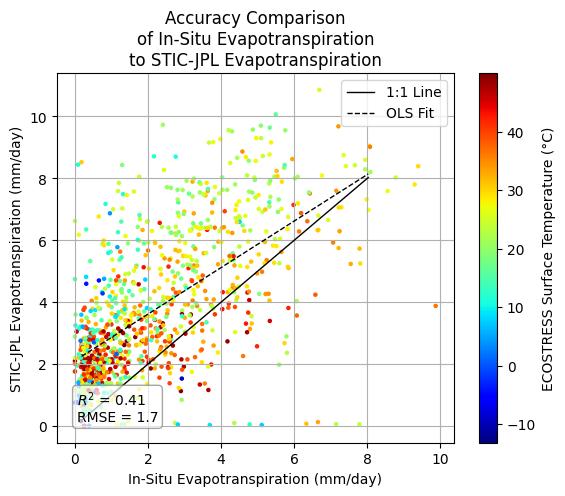

In [10]:
x_variable = "insitu_ET_daylight_kg"
y_variable = "ET_daylight_kg"

sc = plt.scatter(
    x=processed_without_SWin[x_variable],
    y=processed_without_SWin[y_variable],
    c=processed_without_SWin.ST_C,
    cmap="jet",
    color=None,
    s=5
)

# Calculate 5% and 95% tails for x and y variables
x_5th, x_95th = np.percentile(processed_without_SWin[x_variable], [5, 95])
y_5th, y_95th = np.percentile(processed_without_SWin[y_variable], [5, 95])

min_val = min(x_5th, y_5th)
max_val = max(x_95th, y_95th)

# Add 1-to-1 line
# min_val = min(processed[x_variable].min(), processed[y_variable].min())
# max_val = max(processed[x_variable].max(), processed[y_variable].max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

# Add OLS regression line
coefs = np.polyfit(processed_without_SWin[x_variable], processed_without_SWin[y_variable], 1)
ols_x = np.array([min_val, max_val])
ols_y = coefs[0] * ols_x + coefs[1]
plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

# Calculate R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error
y_true = processed_without_SWin[y_variable]
y_pred = coefs[0] * processed_without_SWin[x_variable] + coefs[1]
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Annotate R-squared and RMSE on plot in lower left corner
plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
             xy=(0.05, 0.05), xycoords='axes fraction',
             ha='left', va='bottom',
             fontsize=10,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

# Set ticks every 100 for both axes
# xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
# yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
# plt.xticks(xticks)
# plt.yticks(yticks)

plt.grid(True, zorder=0) 
plt.xlabel("In-Situ Evapotranspiration (mm/day)")
plt.ylabel("STIC-JPL Evapotranspiration (mm/day)")
plt.title("Accuracy Comparison\nof In-Situ Evapotranspiration\nto STIC-JPL Evapotranspiration")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.legend(loc='upper right')
plt.savefig("Accuracy Comparison of In-Situ Evapotranspiration to STIC-JPL Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Accuracy Comparison of In-Situ Evapotranspiration to STIC-JPL Evapotranspiration.svg", format='svg', bbox_inches='tight')
plt.show()

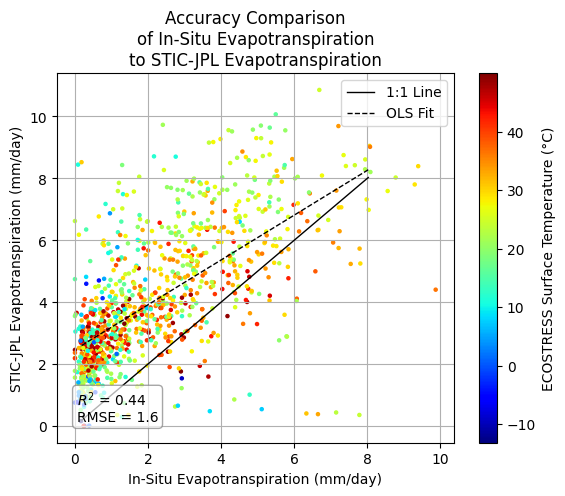

In [11]:
x_variable = "insitu_ET_daylight_kg"
y_variable = "ET_daylight_kg"

sc = plt.scatter(
    x=processed_with_SWin[x_variable],
    y=processed_with_SWin[y_variable],
    c=processed_with_SWin.ST_C,
    cmap="jet",
    color=None,
    s=5
)

# Calculate 5% and 95% tails for x and y variables
x_5th, x_95th = np.percentile(processed_with_SWin[x_variable], [5, 95])
y_5th, y_95th = np.percentile(processed_with_SWin[y_variable], [5, 95])

min_val = min(x_5th, y_5th)
max_val = max(x_95th, y_95th)

# Add 1-to-1 line
# min_val = min(processed[x_variable].min(), processed[y_variable].min())
# max_val = max(processed[x_variable].max(), processed[y_variable].max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

# Add OLS regression line
coefs = np.polyfit(processed_with_SWin[x_variable], processed_with_SWin[y_variable], 1)
ols_x = np.array([min_val, max_val])
ols_y = coefs[0] * ols_x + coefs[1]
plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

# Calculate R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error
y_true = processed_with_SWin[y_variable]
y_pred = coefs[0] * processed_with_SWin[x_variable] + coefs[1]
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Annotate R-squared and RMSE on plot in lower left corner
plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
             xy=(0.05, 0.05), xycoords='axes fraction',
             ha='left', va='bottom',
             fontsize=10,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

# Set ticks every 100 for both axes
# xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
# yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
# plt.xticks(xticks)
# plt.yticks(yticks)

plt.grid(True, zorder=0) 
plt.xlabel("In-Situ Evapotranspiration (mm/day)")
plt.ylabel("STIC-JPL Evapotranspiration (mm/day)")
plt.title("Accuracy Comparison\nof In-Situ Evapotranspiration\nto STIC-JPL Evapotranspiration")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.legend(loc='upper right')
plt.savefig("Accuracy Comparison of In-Situ Evapotranspiration to STIC-JPL Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Accuracy Comparison of In-Situ Evapotranspiration to STIC-JPL Evapotranspiration.svg", format='svg', bbox_inches='tight')
plt.show()

## Plot Unperturbed Comparison of Surface Temperature to Evapotranspiration

This cell creates a scatter plot comparing ECOSTRESS surface temperature to STIC-JPL latent heat flux for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

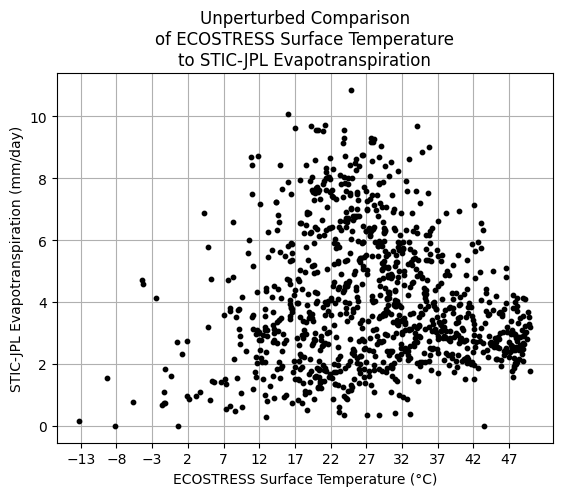

In [12]:
plt.xticks(range(int(min(processed_with_SWin.ST_C)), int(max(processed_with_SWin.ST_C)) + 1, 5))
plt.scatter(x=processed_with_SWin.ST_C, y=processed_with_SWin.ET_daylight_kg, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel("STIC-JPL Evapotranspiration (mm/day)")
plt.title("Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto STIC-JPL Evapotranspiration")
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to STIC-JPL Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to STIC-JPL Evapotranspiration.svg", format='svg', bbox_inches='tight')

plt.show()

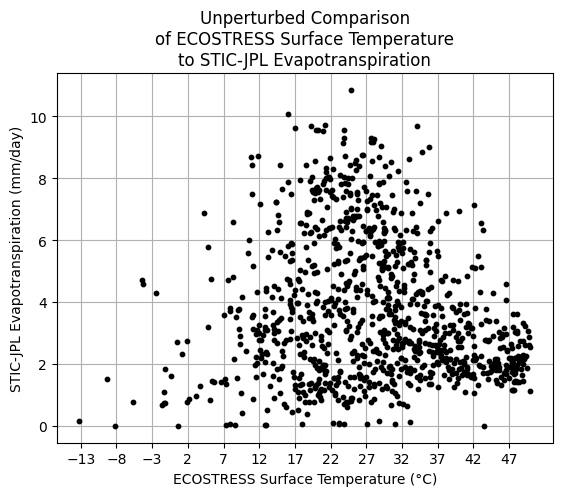

In [13]:
plt.xticks(range(int(min(processed_without_SWin.ST_C)), int(max(processed_without_SWin.ST_C)) + 1, 5))
plt.scatter(x=processed_without_SWin.ST_C, y=processed_without_SWin.ET_daylight_kg, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel("STIC-JPL Evapotranspiration (mm/day)")
plt.title("Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto STIC-JPL Evapotranspiration")
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to STIC-JPL Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to STIC-JPL Evapotranspiration.svg", format='svg', bbox_inches='tight')

plt.show()

## Run Perturbed Model Analysis

This cell sets up the input and output variables for the sensitivity analysis and runs the `perturbed_run` function, which perturbs the input variable and observes the effect on the output variable using the PM-JPL model. The results are displayed for further analysis.

In [14]:
input_variable = "ST_C"
output_variable = "ET_daylight_kg"

results_with_SWin = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=with_SWin,
    normalization_function=normalization_function
)

results_with_SWin = results_with_SWin.dropna()

results_with_SWin

[2026-06-05 15:36:19 INFO] Starting Monte Carlo perturbed run
[2026-06-05 15:36:19 INFO] calculating standard deviation of input variable: ST_C
[2026-06-05 15:36:19 INFO] input variable ST_C standard deviation: 11.251614530435507
[2026-06-05 15:36:19 INFO] starting forward process
[2026-06-05 15:36:19 INFO] started extracting geometry from BESS input table
[2026-06-05 15:36:19 INFO] completed extracting geometry from BESS input table (0.01 seconds)
[2026-06-05 15:36:19 INFO] started extracting time from BESS input table
[2026-06-05 15:36:19 INFO] completed extracting time from BESS input table (0.00 seconds)
[2026-06-05 15:36:19 INFO] started calculating day of year and hour of day
[2026-06-05 15:36:19 INFO] completed calculating day of year and hour of day (0.01 seconds)
[2026-06-05 15:36:19 INFO] started extracting geometry
[2026-06-05 15:36:19 INFO] completed extracting geometry (0.01 seconds)
[2026-06-05 15:36:19 INFO] started retrieving BESS inputs
[2026-06-05 15:36:19 INFO] All G

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.13/site-packages/BESS_JPL/process_BESS_table.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  output_df[key] = value  # Direct assignment overwrites existing columns


[2026-06-05 15:36:19 INFO] starting input perturbation generation
[2026-06-05 15:36:19 INFO] input perturbation generation completed
[2026-06-05 15:36:19 INFO] generating control group
[2026-06-05 15:36:19 INFO] normalizing input perturbations
[2026-06-05 15:36:19 INFO] applying perturbations
[2026-06-05 15:36:19 INFO] starting forward process for perturbed input
[2026-06-05 15:36:20 INFO] started extracting geometry from BESS input table
[2026-06-05 15:36:21 INFO] completed extracting geometry from BESS input table (0.70 seconds)
[2026-06-05 15:36:21 INFO] started extracting time from BESS input table
[2026-06-05 15:36:21 INFO] completed extracting time from BESS input table (0.03 seconds)
[2026-06-05 15:36:21 INFO] started calculating day of year and hour of day
[2026-06-05 15:36:22 INFO] completed calculating day of year and hour of day (0.96 seconds)
[2026-06-05 15:36:22 INFO] started extracting geometry
[2026-06-05 15:36:23 INFO] completed extracting geometry (0.82 seconds)
[2026-

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.13/site-packages/BESS_JPL/process_BESS_table.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  output_df[key] = value  # Direct assignment overwrites existing columns


[2026-06-05 15:36:28 INFO] completed extracting geometry from STIC-JPL input table
[2026-06-05 15:36:28 INFO] started extracting time from STIC-JPL input table
[2026-06-05 15:36:28 INFO] completed extracting time from STIC-JPL input table
[2026-06-05 15:36:30 INFO] variable Ms min: 0.000 mean: 0.246 max: 1.000 nan: 0.00% (nan)
[2026-06-05 15:36:30 INFO] running STIC iteration 1 / 30
[2026-06-05 15:36:30 INFO] using variable Priestley-Taylor alpha with mean: 2.035
[2026-06-05 15:36:30 INFO] completed STIC iteration 1 / 30 with max LE change: 1861.549 (0.013660917000379413 seconds)
[2026-06-05 15:36:30 INFO] variable SM_1 min: 0.000 mean: 0.236 max: 1.000 nan: 0.00% (nan)
[2026-06-05 15:36:30 INFO] variable G_1 min: 0.000 mean: 50.250 max: 158.615 nan: 0.00% (nan)
[2026-06-05 15:36:30 INFO] variable LE_1 min: 0.000 mean: 241.500 max: 1000.000 nan: 0.00% (nan)
[2026-06-05 15:36:30 INFO] running STIC iteration 2 / 30
[2026-06-05 15:36:30 INFO] using variable Priestley-Taylor alpha with mea

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,ET_daylight_kg,31.95,4.077658,0.127626,36.027658,5.580687,-1.695947,0.303896,3.884740
1,ST_C,ET_daylight_kg,31.95,5.040411,0.157759,36.990411,5.580687,-1.94741,0.348955,3.633277
2,ST_C,ET_daylight_kg,31.95,19.655575,0.615198,51.605575,5.580687,-4.272411,0.765571,1.308276
3,ST_C,ET_daylight_kg,31.95,-14.516483,0.454350,17.433517,5.580687,0.61033,0.109365,6.191017
4,ST_C,ET_daylight_kg,31.95,-2.376818,0.074392,29.573182,5.580687,-5.30532,0.950657,0.275367
...,...,...,...,...,...,...,...,...,...,...
101895,ST_C,ET_daylight_kg,41.61,10.471039,0.251647,52.081039,3.848636,-1.652694,0.429423,2.195942
101896,ST_C,ET_daylight_kg,41.61,12.511165,0.300677,54.121165,3.848636,-1.915894,0.497811,1.932742
101897,ST_C,ET_daylight_kg,41.61,-1.247269,0.029975,40.362731,3.848636,0.245569,0.063807,4.094205
101898,ST_C,ET_daylight_kg,41.61,0.945792,0.022730,42.555792,3.848636,-0.176788,0.045935,3.671848


In [15]:
input_variable = "ST_C"
output_variable = "ET_daylight_kg"

results_without_SWin = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=without_SWin,
    normalization_function=normalization_function
)

results_without_SWin = results_without_SWin.dropna()

results_without_SWin

[2026-06-05 15:36:33 INFO] Starting Monte Carlo perturbed run
[2026-06-05 15:36:33 INFO] calculating standard deviation of input variable: ST_C
[2026-06-05 15:36:33 INFO] input variable ST_C standard deviation: 11.251614530435507
[2026-06-05 15:36:33 INFO] starting forward process
[2026-06-05 15:36:33 INFO] started extracting geometry from BESS input table
[2026-06-05 15:36:33 INFO] completed extracting geometry from BESS input table (0.01 seconds)
[2026-06-05 15:36:33 INFO] started extracting time from BESS input table
[2026-06-05 15:36:33 INFO] completed extracting time from BESS input table (0.00 seconds)
[2026-06-05 15:36:33 INFO] started calculating day of year and hour of day
[2026-06-05 15:36:33 INFO] completed calculating day of year and hour of day (0.01 seconds)
[2026-06-05 15:36:33 INFO] started extracting geometry
[2026-06-05 15:36:33 INFO] completed extracting geometry (0.01 seconds)
[2026-06-05 15:36:33 INFO] started retrieving BESS inputs
[2026-06-05 15:36:33 INFO] All G

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.13/site-packages/BESS_JPL/process_BESS_table.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  output_df[key] = value  # Direct assignment overwrites existing columns


[2026-06-05 15:36:33 INFO] starting input perturbation generation
[2026-06-05 15:36:33 INFO] input perturbation generation completed
[2026-06-05 15:36:33 INFO] generating control group
[2026-06-05 15:36:34 INFO] normalizing input perturbations
[2026-06-05 15:36:34 INFO] applying perturbations
[2026-06-05 15:36:34 INFO] starting forward process for perturbed input
[2026-06-05 15:36:34 INFO] started extracting geometry from BESS input table
[2026-06-05 15:36:35 INFO] completed extracting geometry from BESS input table (0.70 seconds)
[2026-06-05 15:36:35 INFO] started extracting time from BESS input table
[2026-06-05 15:36:35 INFO] completed extracting time from BESS input table (0.04 seconds)
[2026-06-05 15:36:35 INFO] started calculating day of year and hour of day
[2026-06-05 15:36:36 INFO] completed calculating day of year and hour of day (0.97 seconds)
[2026-06-05 15:36:36 INFO] started extracting geometry
[2026-06-05 15:36:37 INFO] completed extracting geometry (0.81 seconds)
[2026-

/opt/homebrew/Caskroom/miniforge/base/envs/STIC-JPL/lib/python3.13/site-packages/BESS_JPL/process_BESS_table.py:357: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  output_df[key] = value  # Direct assignment overwrites existing columns


[2026-06-05 15:36:42 INFO] completed extracting geometry from STIC-JPL input table
[2026-06-05 15:36:42 INFO] started extracting time from STIC-JPL input table
[2026-06-05 15:36:43 INFO] completed extracting time from STIC-JPL input table
[2026-06-05 15:36:44 INFO] variable Ms min: 0.000 mean: 0.197 max: 1.000 nan: 0.00% (nan)
[2026-06-05 15:36:44 INFO] running STIC iteration 1 / 30
[2026-06-05 15:36:44 INFO] using variable Priestley-Taylor alpha with mean: 1.681
[2026-06-05 15:36:44 INFO] completed STIC iteration 1 / 30 with max LE change: 1860.486 (0.009448875000089174 seconds)
[2026-06-05 15:36:44 INFO] variable SM_1 min: 0.000 mean: 0.145 max: 1.000 nan: 0.00% (nan)
[2026-06-05 15:36:44 INFO] variable G_1 min: 0.000 mean: 50.319 max: 158.614 nan: 0.00% (nan)
[2026-06-05 15:36:44 INFO] variable LE_1 min: 0.000 mean: 218.385 max: 1000.000 nan: 0.00% (nan)
[2026-06-05 15:36:44 INFO] running STIC iteration 2 / 30
[2026-06-05 15:36:44 INFO] using variable Priestley-Taylor alpha with mea

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,ET_daylight_kg,31.95,1.123300,0.035158,33.0733,5.580687,-0.531492,0.095238,5.049195
1,ST_C,ET_daylight_kg,31.95,-13.367791,0.418397,18.582209,5.580687,0.421282,0.075489,6.001969
2,ST_C,ET_daylight_kg,31.95,5.612841,0.175676,37.562841,5.580687,-2.082722,0.373202,3.497965
3,ST_C,ET_daylight_kg,31.95,-4.330041,0.135526,27.619959,5.580687,-5.521143,0.98933,0.059544
4,ST_C,ET_daylight_kg,31.95,-1.986843,0.062186,29.963157,5.580687,-2.054528,0.36815,3.526159
...,...,...,...,...,...,...,...,...,...,...
101895,ST_C,ET_daylight_kg,41.61,11.012477,0.264659,52.622477,3.157289,-1.688268,0.534721,1.469022
101896,ST_C,ET_daylight_kg,41.61,1.775514,0.042670,43.385514,3.157289,-0.349825,0.110799,2.807464
101897,ST_C,ET_daylight_kg,41.61,4.580022,0.110070,46.190022,3.157289,-0.831098,0.263231,2.326192
101898,ST_C,ET_daylight_kg,41.61,21.045568,0.505781,62.655568,3.157289,-2.376193,0.752605,0.781096


## Plot Change in Surface Temperature vs Latent Heat Flux

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in PM-JPL latent heat flux due to input perturbations. The plot is saved as JPEG and SVG files.

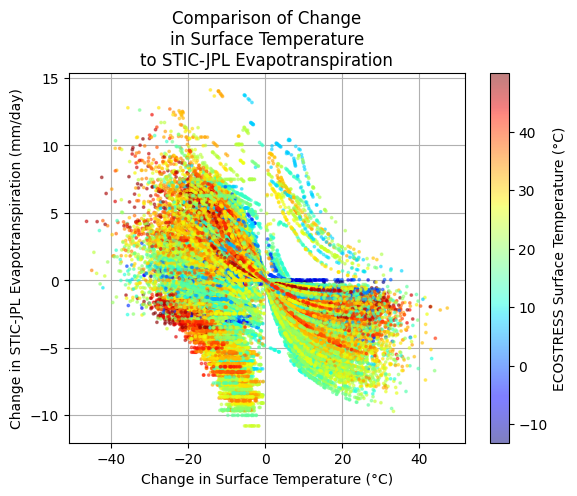

In [16]:
sc = plt.scatter(
    x=results_without_SWin.input_perturbation, 
    y=results_without_SWin.output_perturbation, 
    c=results_without_SWin.input_unperturbed, 
    color=None,
    cmap="jet",
    s=3,
    alpha=0.5, 
    zorder=5
)

plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in STIC-JPL Evapotranspiration (mm/day)")
plt.title("Comparison of Change\nin Surface Temperature\nto STIC-JPL Evapotranspiration")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.savefig("Comparison of Change in Surface Temperature to STIC-JPL Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to STIC-JPL Evapotranspiration.svg", format='svg', bbox_inches='tight')
plt.show()

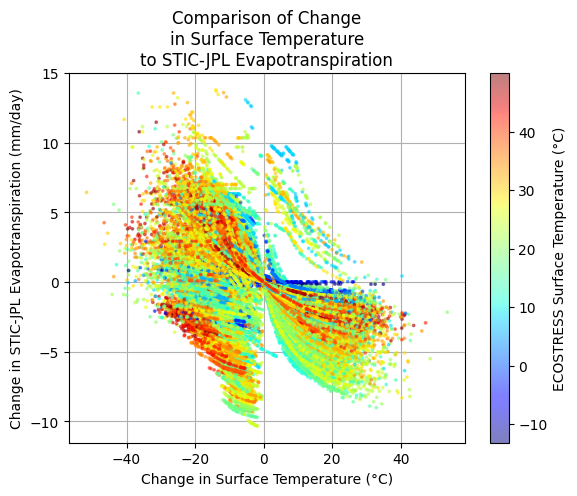

In [17]:
sc = plt.scatter(
    x=results_with_SWin.input_perturbation, 
    y=results_with_SWin.output_perturbation, 
    c=results_with_SWin.input_unperturbed, 
    color=None,
    cmap="jet",
    s=3,
    alpha=0.5, 
    zorder=5
)

plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in STIC-JPL Evapotranspiration (mm/day)")
plt.title("Comparison of Change\nin Surface Temperature\nto STIC-JPL Evapotranspiration")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.savefig("Comparison of Change in Surface Temperature to STIC-JPL Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to STIC-JPL Evapotranspiration.svg", format='svg', bbox_inches='tight')
plt.show()

## Compute Correlation Between Input and Output Perturbations

This cell calculates the Pearson correlation coefficient between the standardized input and output perturbations, quantifying the strength of their linear relationship.

In [19]:
correlation = mstats.pearsonr(
    np.array(results_without_SWin.input_perturbation_std).astype(np.float64), 
    np.array(results_without_SWin.output_perturbation_std).astype(np.float64)
)[0]

correlation

np.float64(0.0641440193408381)

In [20]:
correlation = mstats.pearsonr(
    np.array(results_with_SWin.input_perturbation_std).astype(np.float64), 
    np.array(results_with_SWin.output_perturbation_std).astype(np.float64)
)[0]

correlation

np.float64(0.09048447141834036)

## Run Full Sensitivity Analysis for Multiple Inputs

This cell performs a comprehensive sensitivity analysis by perturbing several input variables (surface temperature, NDVI, albedo, air temperature, relative humidity) and measuring their effect on latent heat flux. The results are summarized in a DataFrame.

In [ ]:
input_variables = ["ST_C", "NDVI", "albedo", "Ta_C", "RH"]
output_variables = ["ET_daylight_kg"]

perturbation_df, sensitivity_metrics_df = sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variables=output_variables,
    forward_process=forward_process,
    normalization_function=normalization_function
)

sensitivity_metrics_df

## Plot Sensitivity Magnitude Bar Chart

This cell creates a bar chart showing the average percent change in latent heat flux for each input variable, visualizing the magnitude of model sensitivity to each input. The plot is saved as JPEG and SVG files with the PT-JPL-SM label.

In [ ]:
df = sensitivity_metrics_df
df = df[(df.output_variable == "ET_daylight_kg") & (df.metric == "mean_normalized_change")]
ax = sns.barplot(x=df.input_variable, y=df.value * 100, color='black')
ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])
plt.xlabel("Input Variable")
plt.ylabel("Average Percent Change in Output Perturbation")
plt.title("STIC-JPL Evapotranspiration Sensitivity Magnitude")
# plt.ylim(0, 160)  # Set y-axis range from 0 to 160
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5)  # Add light gray horizontal gridlines only

# Add percent sign to y-axis tick labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.savefig("STIC-JPL Evapotranspiration Sensitivity Magnitude.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("STIC-JPL Evapotranspiration Sensitivity Magnitude.svg", format='svg', bbox_inches='tight')
plt.show()

## Summary and Next Steps

This notebook demonstrated a full sensitivity analysis workflow for the PT-JPL-SM model using ECOSTRESS Cal-Val data. Key results include the identification of input variables with the greatest influence on latent heat flux. Next steps could include further exploration of model parameters, additional visualizations, or application to other datasets.